### ESAM 495 Assignment 3: _E. Coli_ Metabolic Network Analysis & FBA

Author: Phoebe Kuang

Date: May 12, 2026

**References**: 

1. Documentation for COBRApy https://cobrapy.readthedocs.io/en/latest/index.html

2. The COBRA Toolbox Flux Balance Analysis https://opencobra.github.io/cobratoolbox/stable/tutorials/tutorial_FBA.html 

---

#### **Part 0.  Installation \& Environment Setup**

_Please run the following command lines in the terminal to setup the environment and install `CobraPy` package first._

`conda create -n cobra_env python=3.11 -y`

`conda activate cobra_env`

`conda install -c conda-forge cobra notebook ipykernel -y`

_Please make sure to select the conda_env kernel in your Jupyter Notebook. Then you can run the following cell to verify that the setup._


In [1]:
# Installation Test
import cobra

# Load the E. coli core model
model = cobra.io.load_model("textbook")

print(f"COBRApy version: {cobra.__version__}")
print(f"Model ID: {model.id}")
print(f"Number of Metabolites: {len(model.metabolites)}")
print(f"Number of Reactions: {len(model.reactions)}")

COBRApy version: 0.31.1
Model ID: e_coli_core
Number of Metabolites: 72
Number of Reactions: 95


After setting up correctly, we can do some first explorations on the _E. Coli_ model

In [2]:
model

Name,e_coli_core
Memory address,1a9bc929650
Number of metabolites,72
Number of reactions,95
Number of genes,137
Number of groups,0
Objective expression,1.0*Biomass_Ecoli_core - 1.0*Biomass_Ecoli_core_reverse_2cdba
Compartments,"cytosol, extracellular"


In [3]:
vars(model).keys()

dict_keys(['_id', 'name', 'notes', '_annotation', 'genes', 'reactions', 'metabolites', 'groups', '_compartments', '_contexts', '_solver', '_tolerance', '_sbml'])

In [4]:
model.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
glc__D_e,EX_glc__D_e,10,6,100.00%
nh4_e,EX_nh4_e,4.765,0,0.00%
o2_e,EX_o2_e,21.8,0,0.00%
pi_e,EX_pi_e,3.215,0,0.00%
Metabolite,Reaction,Flux,C-Number,C-Flux
co2_e,EX_co2_e,-22.81,1,100.00%
h2o_e,EX_h2o_e,-29.18,0,0.00%
h_e,EX_h_e,-17.53,0,0.00%


---
Now we can officially follow the FBA tutorial to play around with this package and do some fun Metabolic Network Analysis/Flux Balance Analysis (FBA).


In [5]:
# We will gather all the packages that will be used here for clearity.
# Make sure you have all the packages installed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import escher
from cobra.util.array import create_stoichiometric_matrix
from escher import Builder


plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "figure.dpi": 300,
})

import warnings
warnings.filterwarnings('ignore')


#### **Part 1: Analyze the _E. coli_ Core Metabolism Network Model**

##### **Q 1.1**: What is the overall size of the model, in terms of the stochiometry matrix reactions, and metabolites?


In [6]:
# Extract the Stoichiometric Matrix (S)
S = create_stoichiometric_matrix(model)
print(f"Shape of S matrix: {S.shape} (Metabolites x Reactions)")

Shape of S matrix: (72, 95) (Metabolites x Reactions)


##### **Q 1.2**: What is the connectivity of the metabolites and reactions like? Use the binary form of S. Make a plot to characterize how many reactions each metabolite participates in. Are there any notably highly connected metabolites?

In [7]:
# Connectivity Analysis (Binary S)

# Convert to binary: True if non-zero, False if zero, then to integers (1 or 0)
S_binary = (S != 0).astype(int)

# Sum across the rows (axis=1) to see how many reactions each metabolite is in
metabolite_connectivity = np.sum(S_binary, axis=1)

# Find the names of the most connected metabolites
met_names = np.array([m.id for m in model.metabolites])
sorted_indices = np.argsort(metabolite_connectivity)[::-1] # Decending order

print("\n --- Top 10 Most Connected Metabolites ---")
for i in range(10):
    idx = sorted_indices[i]
    print(f"{met_names[idx]}: participates in {metabolite_connectivity[idx]} reactions")


 --- Top 10 Most Connected Metabolites ---
h_c: participates in 35 reactions
h2o_c: participates in 18 reactions
h_e: participates in 17 reactions
atp_c: participates in 13 reactions
pi_c: participates in 12 reactions
adp_c: participates in 12 reactions
nad_c: participates in 12 reactions
nadh_c: participates in 12 reactions
pyr_c: participates in 11 reactions
co2_c: participates in 9 reactions


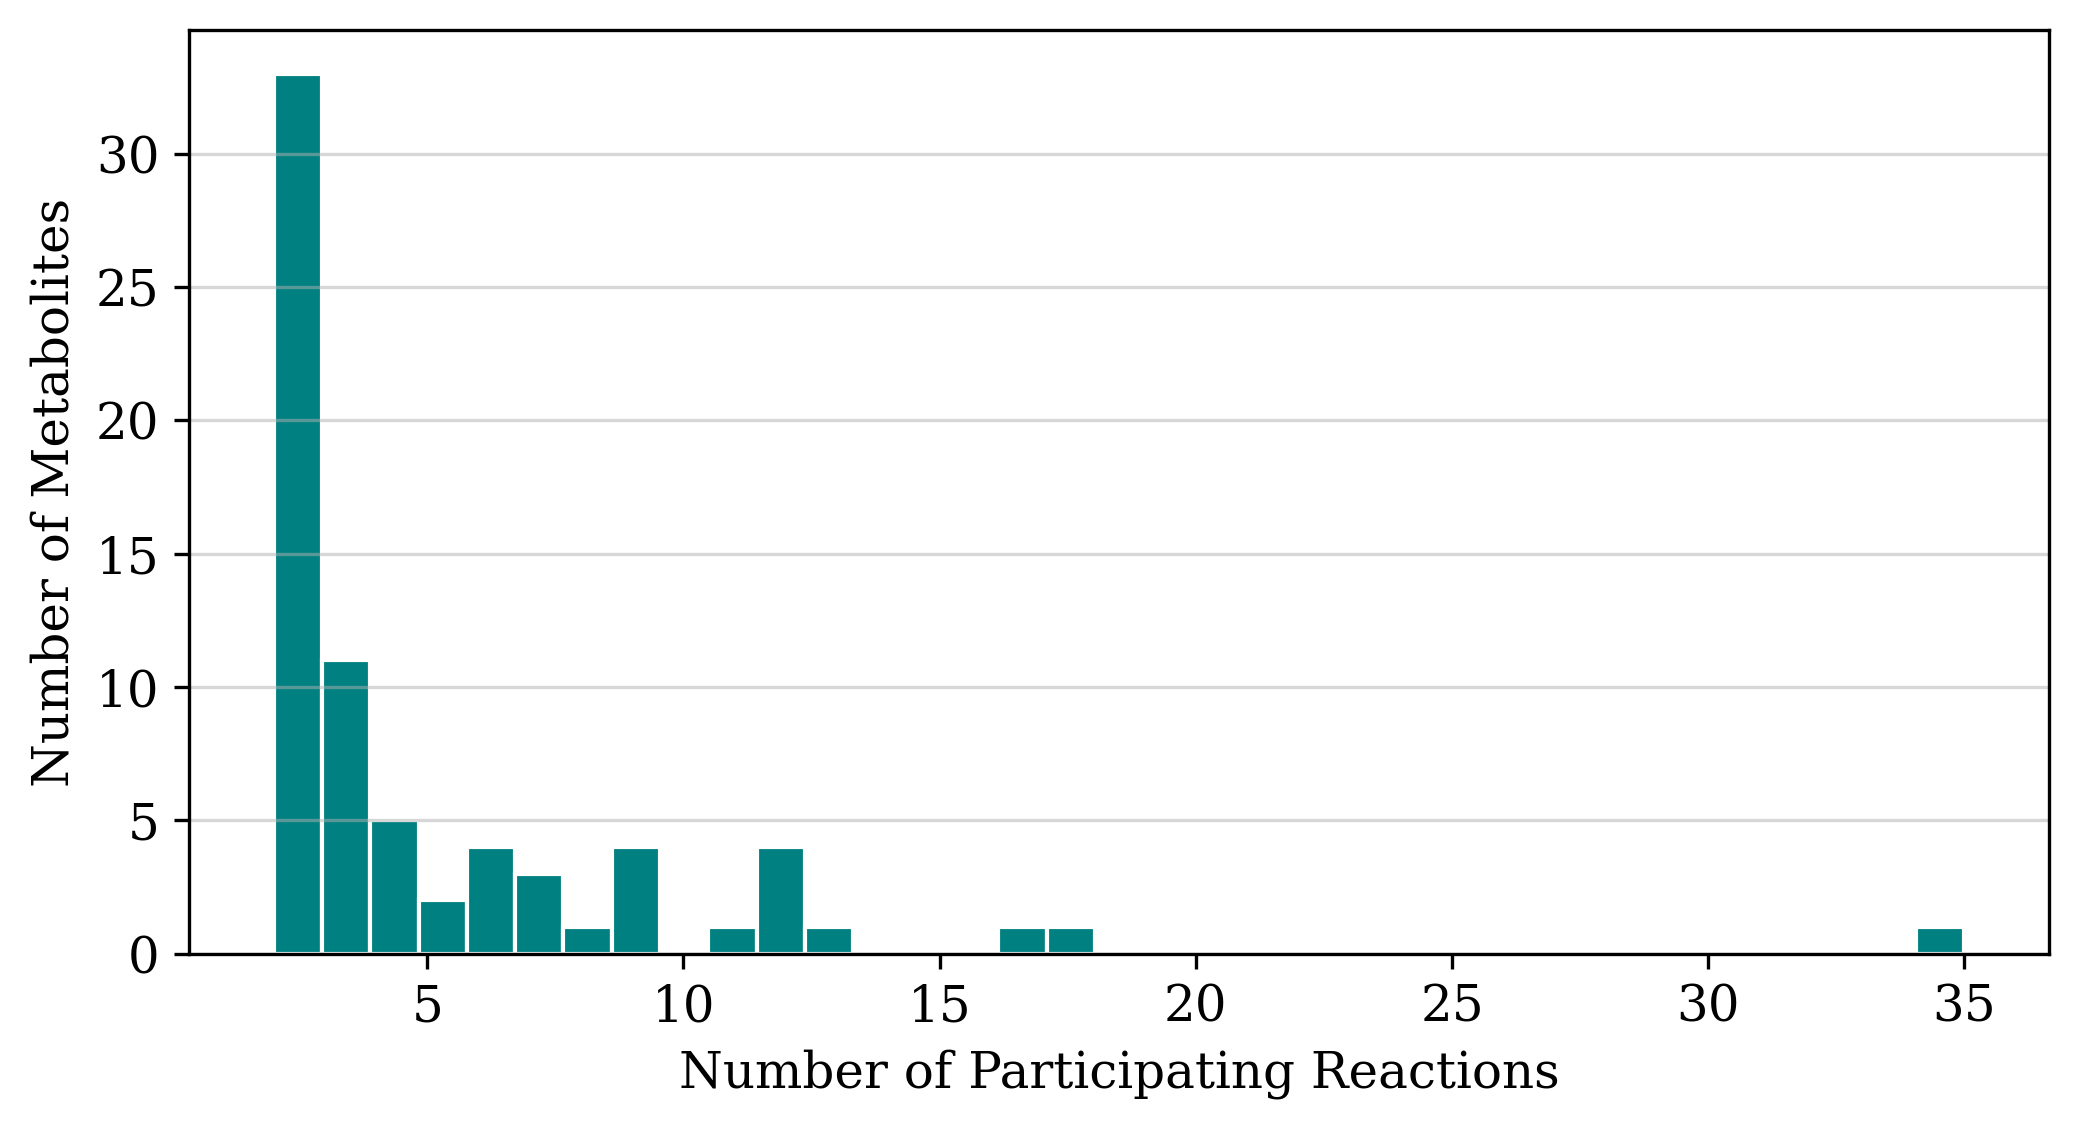

In [8]:
# Connectivity Histogram
plt.figure(figsize=(8, 4))
plt.hist(metabolite_connectivity, bins=35, color='teal', edgecolor="white")
plt.xlabel('Number of Participating Reactions')
plt.ylabel('Number of Metabolites')
plt.grid(axis='y', alpha=0.5)
plt.show()

##### **Q 1.3:**: Take the SVD of the stochiometry matrix S and plot the singular values What does this tell us about the size of the subspaces of S? How does numerical error influence this result?

In [9]:
# Take the SVD of the S matrix
U, Sigma, VT = np.linalg.svd(S)

In [10]:
Sigma

array([1.35576379e+02, 1.04917609e+01, 5.34668872e+00, 4.80804629e+00,
       4.47616412e+00, 3.86636670e+00, 3.74856612e+00, 3.53945158e+00,
       3.37784920e+00, 3.05018394e+00, 2.82511084e+00, 2.67948718e+00,
       2.56947177e+00, 2.49387211e+00, 2.27788720e+00, 2.23348975e+00,
       2.18474011e+00, 2.08341122e+00, 2.02413100e+00, 1.94299774e+00,
       1.90069833e+00, 1.86492269e+00, 1.81520373e+00, 1.80488293e+00,
       1.77341039e+00, 1.73002699e+00, 1.71942972e+00, 1.68493318e+00,
       1.63013179e+00, 1.62177233e+00, 1.61564587e+00, 1.58952561e+00,
       1.56313025e+00, 1.49623574e+00, 1.48851733e+00, 1.45818256e+00,
       1.41796702e+00, 1.39280673e+00, 1.37815718e+00, 1.37297574e+00,
       1.34411573e+00, 1.32761085e+00, 1.30186206e+00, 1.27543056e+00,
       1.24477011e+00, 1.23826369e+00, 1.18306315e+00, 1.18008310e+00,
       1.06492538e+00, 1.03350334e+00, 9.95082335e-01, 9.62696572e-01,
       9.27257701e-01, 8.95597554e-01, 8.36636263e-01, 7.84463297e-01,
      

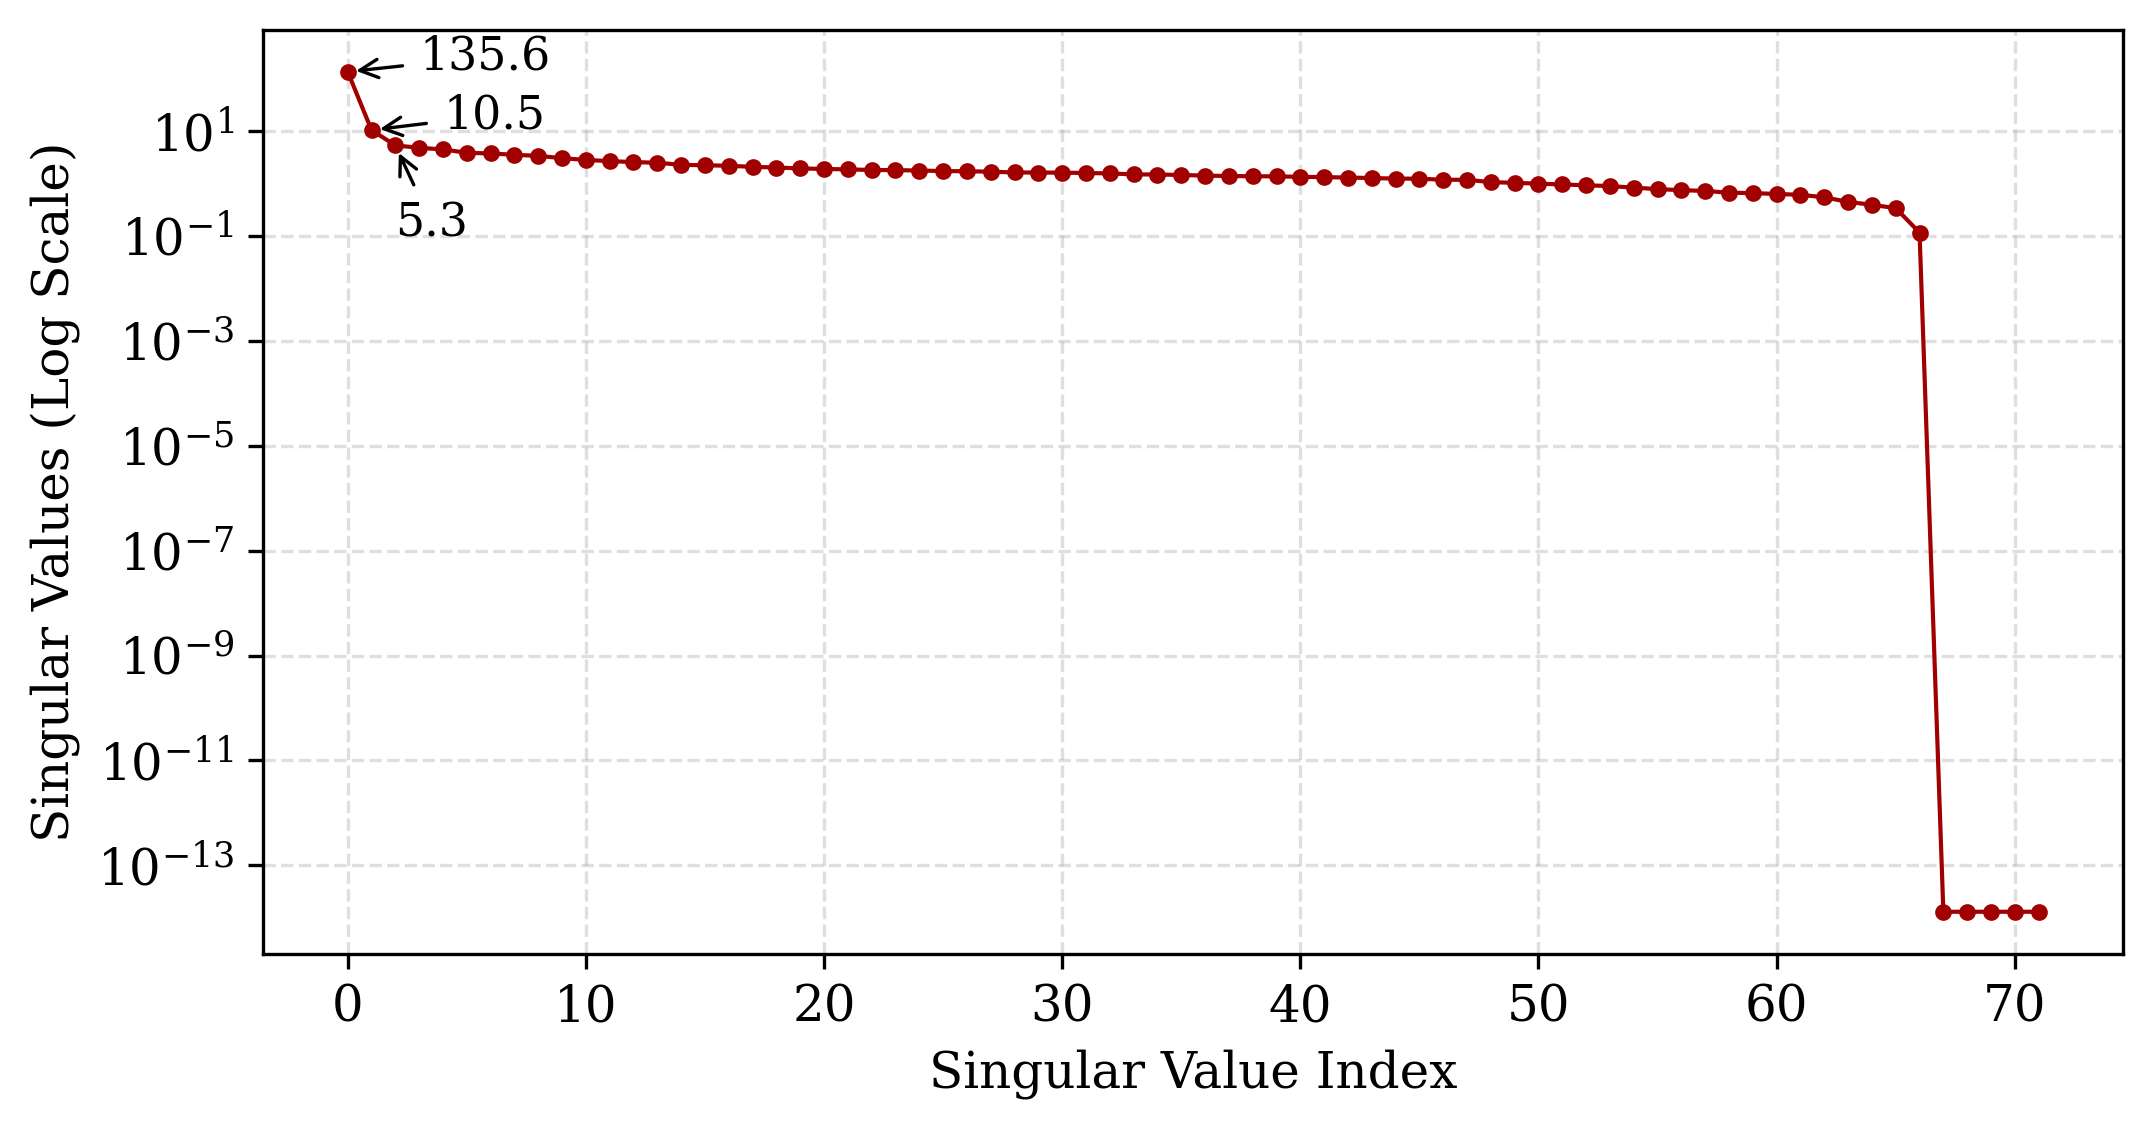

In [11]:
# Plot the singular values (on log scale)
plt.figure(figsize=(8, 4))
for i in range(2):
    plt.annotate(f"{Sigma[i]:.1f}", 
                 xy=(i, Sigma[i]), 
                 xytext=(i + 3, Sigma[i] * 1.1),
                 fontsize=11,
                 arrowprops=dict(arrowstyle="->", color='black', lw=0.8))
plt.annotate(f"{Sigma[2]:.1f}", 
                 xy=(2, Sigma[2]), 
                 xytext=(2, 0.1),
                 fontsize=11,
                 arrowprops=dict(arrowstyle="->", color='black', lw=0.8))
plt.plot(Sigma, marker='o', linestyle='-', color='#a00000', markersize=3, lw=1)
plt.xlabel('Singular Value Index')
plt.ylabel('Singular Values (Log Scale)')
plt.yscale('log') # Use log scale to see the numerical error
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.show()

In [12]:
# Define numerical zero (we will consider everything below this 0)
tolerance = 1e-10

# Compute Rank
rank = np.sum(Sigma > tolerance)

print("--- Fundamental Subspaces of S ---\n")
print(f"S Matrix: {S.shape[0]} metabolites x {S.shape[1]} reactions\n")
print(f"Rank (r) / Column Space / Row Space: {rank}\n")
print(f"Null Space (n - r): {S.shape[1] - rank}\n")
print(f"Left Null Space (m - r): {S.shape[0] - rank}\n")

--- Fundamental Subspaces of S ---

S Matrix: 72 metabolites x 95 reactions

Rank (r) / Column Space / Row Space: 67

Null Space (n - r): 28

Left Null Space (m - r): 5



---

#### **Part 2: Analyze Constraints/Bounds \& Optimize**

##### **Q 2.1**: (MATLAB) Use the `printConstraints` functionto determine how many reactions are reversible and how many are irreversible. It may also help to analyze the lowerbound and upperbound vectors (`lb` and `ub`).


_Note: `COBRApy` doesn't have a direct `printConstraints` command (because Python is object-oriented). Instead, every reaction object has `.lower_bound` and `.upper_bound` attributes:_

_If lower_bound < 0 and upper_bound > 0, the reaction is reversible. Otherwise, it is irreversible._

In [13]:
# MATLAB equivalent: 
# `printConstraints(model,-1000,1000)` followed by checking `model.lb` and `model.ub`

reversible_count = 0
irreversible_count = 0

# Check each of the 95 reactions in the model
for rxn in model.reactions:
    # Check the bounds
    if rxn.lower_bound < 0 and rxn.upper_bound > 0:
        reversible_count += 1
    else:
        irreversible_count += 1

print(f"Total Reactions: {len(model.reactions)}")
print(f"Reversible Reactions: {reversible_count}")
print(f"Irreversible Reactions: {irreversible_count}")

# Some examples
print("\nExamples of Exchange Reaction Bounds (lb, ub):")
print(f"EX_glc__D_e: ({model.reactions.EX_glc__D_e.lower_bound}, {model.reactions.EX_glc__D_e.upper_bound})")
print(f"ATPM: ({model.reactions.ATPM.lower_bound}, {model.reactions.ATPM.upper_bound})")
print(f"EX_o2_e: ({model.reactions.EX_o2_e.lower_bound}, {model.reactions.EX_o2_e.upper_bound})")

Total Reactions: 95
Reversible Reactions: 46
Irreversible Reactions: 49

Examples of Exchange Reaction Bounds (lb, ub):
EX_glc__D_e: (-10.0, 1000.0)
ATPM: (8.39, 1000.0)
EX_o2_e: (-1000.0, 1000.0)


##### **Q 2.2**: What does changing the bound of oxygen flux to -1000 do? Is -1000 physically reasonable?

In [14]:
# changeRxnBounds
# MATLAB: model = changeRxnBounds(model, 'EX_o2(e)', -1000, 'l');
# Python: Access the reaction by ID and modify the .lower_bound or .upper_bound.
# Note: COBRApy changes '(' to '_' in IDs, so 'EX_o2(e)' becomes 'EX_o2_e'

model.reactions.EX_o2_e.lower_bound = -1000
print(f"Oxygen Flux Lower Bound: {model.reactions.EX_o2_e.lower_bound}")

Oxygen Flux Lower Bound: -1000


##### **Q 2.3**: Replace the command to change the objective in the tutorial with
`model = changeObjective(model,’Biomass Ecoli core w GAM’);`

In [15]:
# changeObjective
# MATLAB: model = changeObjective(model, 'Biomass_Ecoli_core_w_GAM');
# Python: Assign the reaction ID directly to model.objective.

biomass_rxn = model.reactions.get_by_id("Biomass_Ecoli_core")
model.objective = biomass_rxn
model.objective

In [16]:
# Run FBA (with original default settings/bounds)

solution_default = model.optimize()

print(f"Linear programming solver status: {solution_default.status}")
print(f"Objective value (optimal growth rate): {solution_default.objective_value:.4f} hr^-1")

Linear programming solver status: optimal
Objective value (optimal growth rate): 0.8739 hr^-1


##### **Q 2.4**: What metabolites contribute to the objective function for the example 1? Plot a bar plot of the fluxes making up 75% of the flux. Identify the top 5 reactions.

Metabolites contributing to the Biomass Objective:
  3pg_c: -1.496
  accoa_c: -3.7478
  atp_c: -59.81
  e4p_c: -0.361
  f6p_c: -0.0709
  g3p_c: -0.129
  g6p_c: -0.205
  gln__L_c: -0.2557
  glu__L_c: -4.9414
  h2o_c: -59.81
  nad_c: -3.547
  nadph_c: -13.0279
  oaa_c: -1.7867
  pep_c: -0.5191
  pyr_c: -2.8328
  r5p_c: -0.8977
  adp_c: 59.81
  akg_c: 4.1182
  coa_c: 3.7478
  h_c: 59.81
  nadh_c: 3.547
  nadp_c: 13.0279
  pi_c: 59.81

Objective value (optimal growth rate) for Example 1: 1.6531 hr^-1

Top 5 Reactions (by Absolute Flux):
ATPS4r      80.606869
CYTBD       77.483169
NADH16      68.900971
EX_h2o_e    52.694337
H2Ot        52.694337
Name: fluxes, dtype: float64


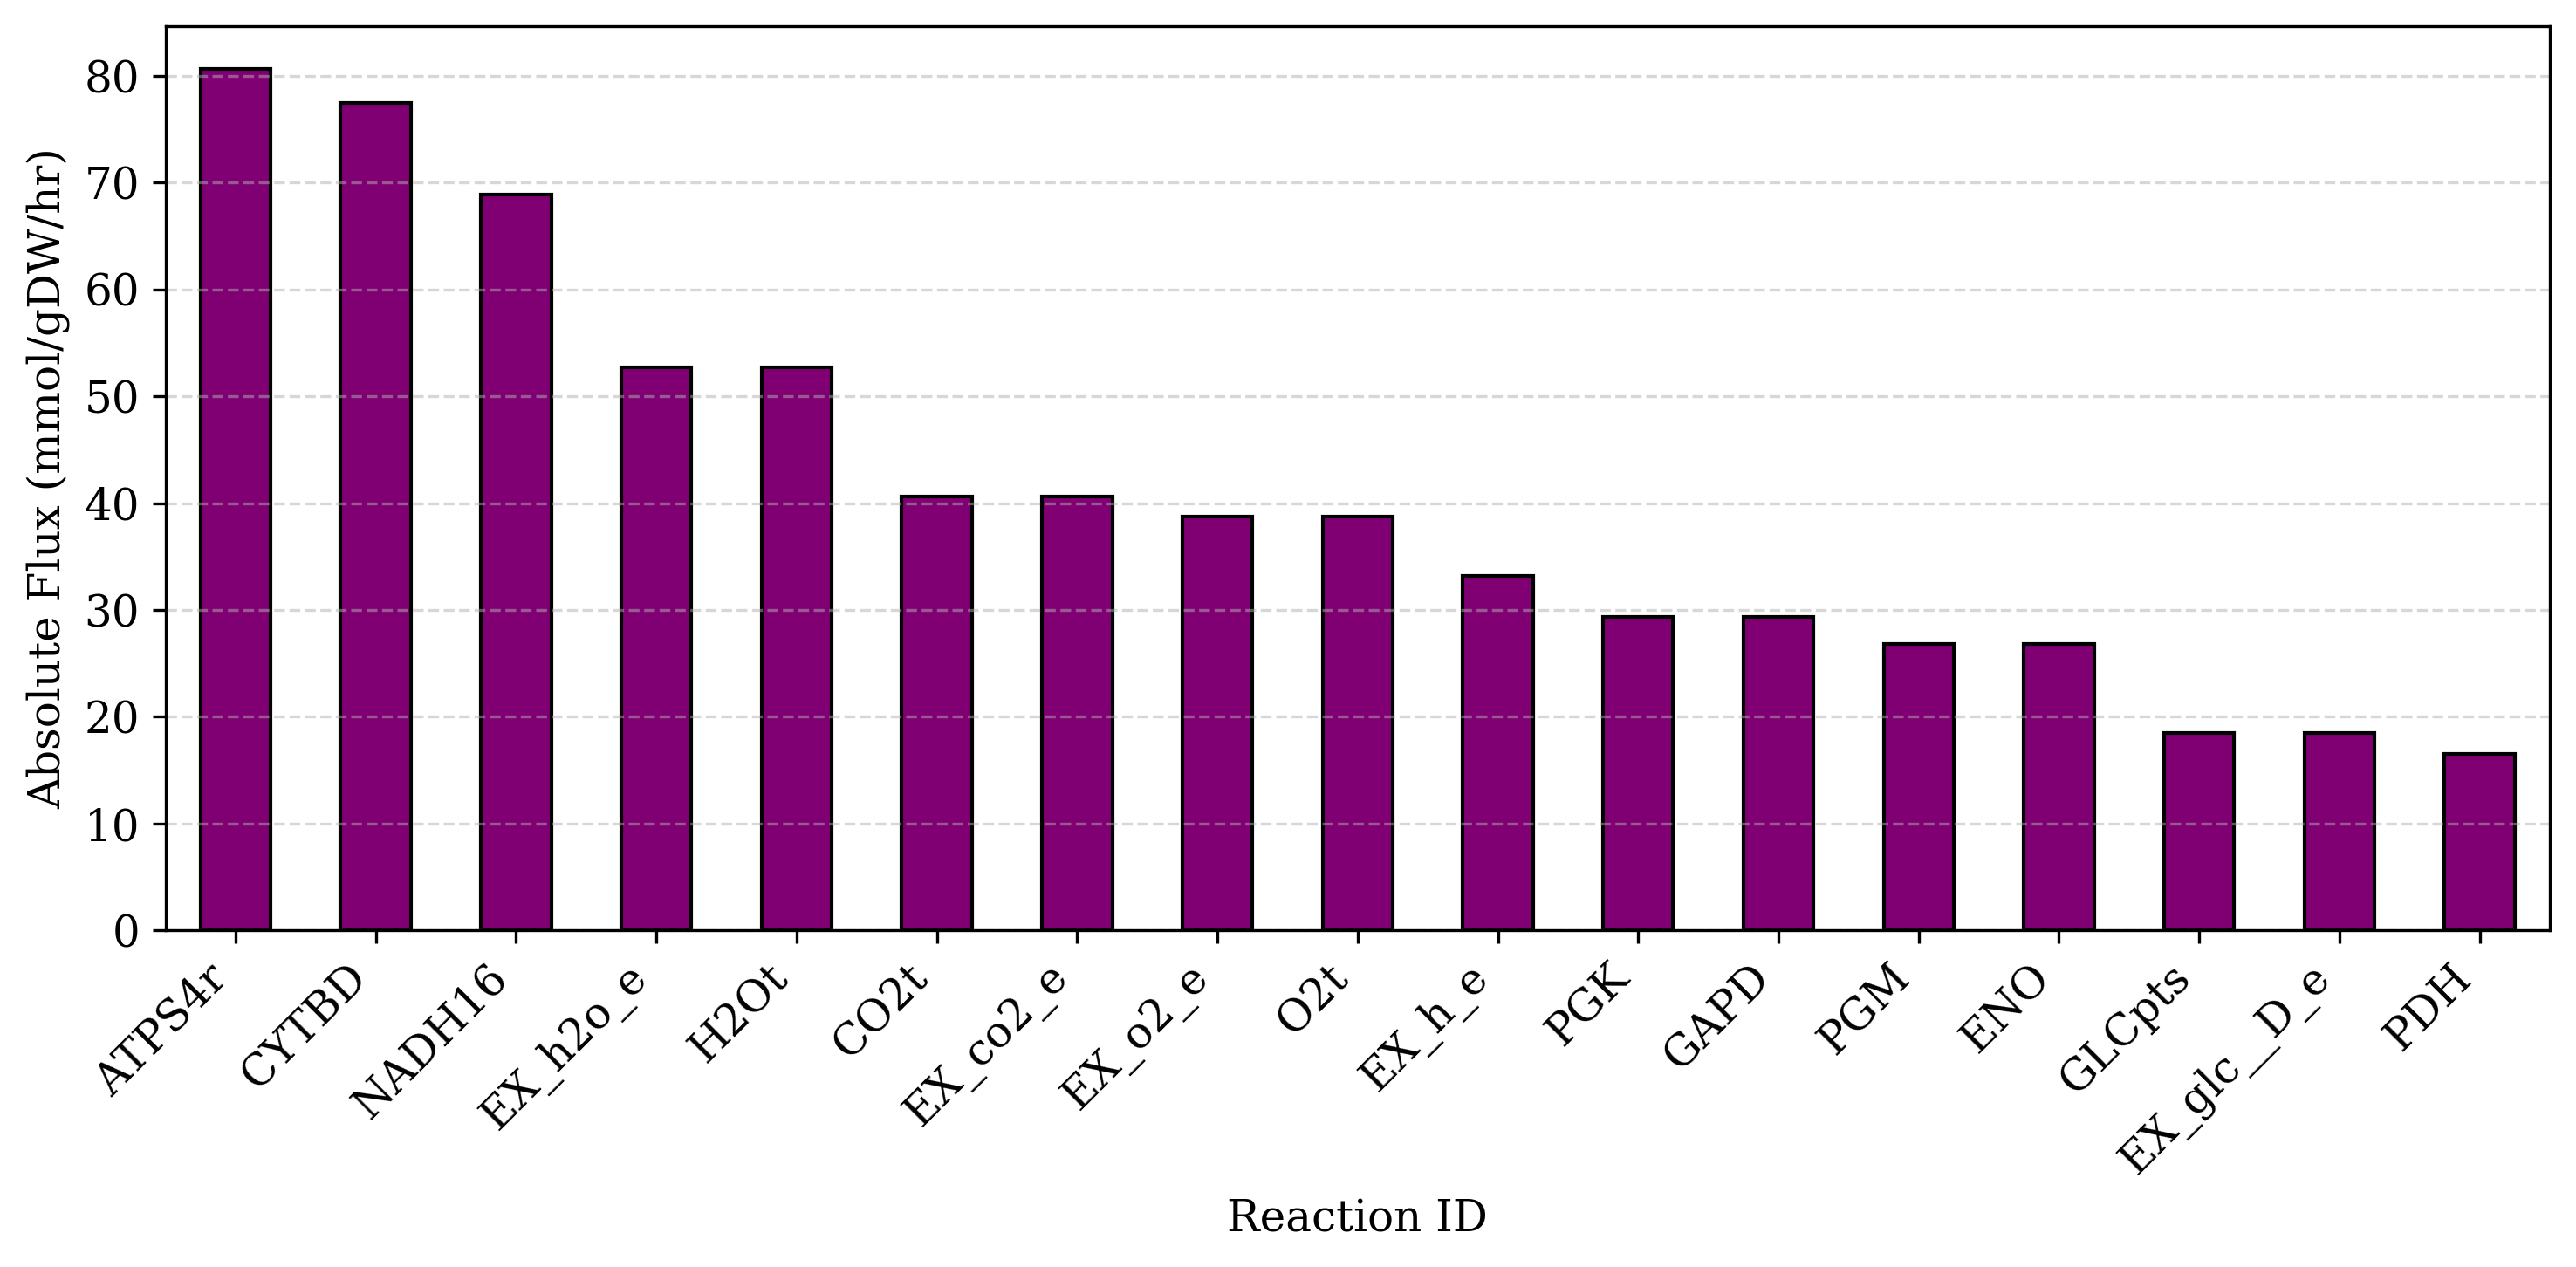

In [17]:
# MATLAB Tutorial Example 1 Replicate & Analysis

# Set glucose uptake to -18.5
model.reactions.EX_glc__D_e.lower_bound = -18.5

print("Metabolites contributing to the Biomass Objective:")
# Print the metabolite ID and its stoichiometric coefficient
for metabolite, coefficient in biomass_rxn.metabolites.items():
    print(f"  {metabolite.id}: {coefficient}")

# Run FBA (with modified glucose uptake rate)
solution = model.optimize()
print(f"\nObjective value (optimal growth rate) for Example 1: {solution.objective_value:.4f} hr^-1")

# Fluxes Analysis
# Extract fluxes, take absolute value, and sort
fluxes = pd.Series(solution.fluxes)
abs_fluxes = fluxes[fluxes != 0].abs().sort_values(ascending=False)

# Calculate cumulative sum as a percentage of total absolute flux
cumulative_percent = abs_fluxes.cumsum() / abs_fluxes.sum()

# Filter for the reactions that make up the first 75%
top_75_fluxes = abs_fluxes[cumulative_percent <= 0.75]

print("\nTop 5 Reactions (by Absolute Flux):")
print(top_75_fluxes.head(5))

# Plot the Top Reactions (75% of total flux)
plt.figure(figsize=(10, 5))
top_75_fluxes.plot(kind='bar', color='#800074', edgecolor='black')
plt.ylabel('Absolute Flux (mmol/gDW/hr)')
plt.xlabel('Reaction ID')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [18]:
# MATLAB Equivalent (from Tutorial Example 1)
# fluxData = FBAsolution.v;
# nonZeroFlag = 1;
# printFluxVector(model, fluxData, nonZeroFlag)

# The output should match

print(fluxes[fluxes != 0])

ACONTa                10.365697
ACONTb                10.365697
AKGDH                  8.582198
ATPM                   8.390000
ATPS4r                80.606869
Biomass_Ecoli_core     1.653072
CO2t                 -40.652701
CS                    10.365697
CYTBD                 77.483169
ENO                   26.839054
EX_co2_e              40.652701
EX_glc__D_e          -18.500000
EX_h_e                33.160621
EX_h2o_e              52.694337
EX_nh4_e              -9.013870
EX_o2_e              -38.741584
EX_pi_e               -6.081155
FBA                   13.562100
FUM                    8.582198
G6PDH2r                9.880769
GAPD                  29.312050
GLCpts                18.500000
GLNS                   0.422690
GLUDy                 -8.591180
GND                    9.880769
H2Ot                 -52.694337
ICDHyr                10.365697
MDH                    8.582198
NADH16                68.900971
NH4t                   9.013870
O2t                   38.741584
PDH     

---

#### **Part 3: Growth on Different Substrates and Network Visualization**

##### **Q 3.1**: Produce your own plot via Example 2. Then proceed to Example 3 and produce a similar plot. Quantitatively compare how much the flux has shifted between the different pathways in Example 1 and Example 3.

_Note: Producing the metabolic network maps in Python relies on the `Escher` package. If you haven't installed it already, please run the following command line in your terminal (make sure you are still using `cobra_env` kernel._

`pip install escher`

_After installing, the Jupyter notebook extension should be installed automatically. You can check this by running:_

`jupyter nbextension list`


`Escher` Documentation: https://escher.readthedocs.io/en/latest/index.html

_Note: The format cannot be rendered in HTML. Please see maps for Example 2 and 3 in the jupyter notebook or in the writeup._


In [19]:
# Example 2: Display the optimal flux vector (aerobic) on a metabolic map

# We use the 'solution.fluxes' we calculated from Example 1
builder_aerobic = Builder(
    map_name='e_coli_core.Core metabolism',
    model_name='e_coli_core',
    reaction_data=solution.fluxes
)

print("Aerobic Flux Map (Example 2):")
builder_aerobic

Aerobic Flux Map (Example 2):


Builder(reaction_data={'ACALD': np.float64(0.0), 'ACALDt': np.float64(0.0), 'ACKr': np.float64(0.0), 'ACONTa':…

In [20]:
# Example 3: Anaerobic Growth

# Set oxygen uptake to 0
model.reactions.EX_o2_e.lower_bound = 0

# Run the FBA (optimization)
solution_anaerobic = model.optimize()
print(f"Anaerobic Growth Rate: {solution_anaerobic.objective_value:.4f} hr^-1")

# Draw the Anaerobic Map
builder_anaerobic = Builder(
    map_name='e_coli_core.Core metabolism',
    model_name='e_coli_core',
    reaction_data=solution_anaerobic.fluxes
)

print("\nAnaerobic Flux Map (Example 3):")
builder_anaerobic

Anaerobic Growth Rate: 0.4706 hr^-1

Anaerobic Flux Map (Example 3):


Builder(reaction_data={'ACALD': np.float64(-14.674916893771446), 'ACALDt': np.float64(0.0), 'ACKr': np.float64…

In [21]:
# printFluxVector Equivalence

# Combine all fluxes into one DataFrame
df_all = pd.DataFrame({
    'Aerobic': solution.fluxes,
    'Anaerobic': solution_anaerobic.fluxes
})

# Filter for Exchange reactions (EX_) and Biomass (Replicating excFlag = 1)
rxn_ids = [rxn.id for rxn in model.reactions if rxn.id.startswith('EX_') or 'biomass' in rxn.id.lower()]
df_exc = df_all.loc[rxn_ids]

# Filter out rows where BOTH fluxes are basically zero (Replicating nonZeroFlag = 1)
# We use 1e-8 to account for numerical solver noise
df_exc = df_exc[(df_exc['Aerobic'].abs() > 1e-8) | (df_exc['Anaerobic'].abs() > 1e-6)]

print("Exchange & Biomass Fluxes (Aerobic vs Anaerobic):\n")
print(df_exc.round(4))

Exchange & Biomass Fluxes (Aerobic vs Anaerobic):

                    Aerobic  Anaerobic
Biomass_Ecoli_core   1.6531     0.4706
EX_ac_e              0.0000    15.1732
EX_co2_e            40.6527    -0.8408
EX_etoh_e            0.0000    14.6749
EX_for_e             0.0000    32.1194
EX_glc__D_e        -18.5000   -18.5000
EX_h_e              33.1606    56.7321
EX_h2o_e            52.6943   -12.0879
EX_nh4_e            -9.0139    -2.5659
EX_o2_e            -38.7416     0.0000
EX_pi_e             -6.0812    -1.7311


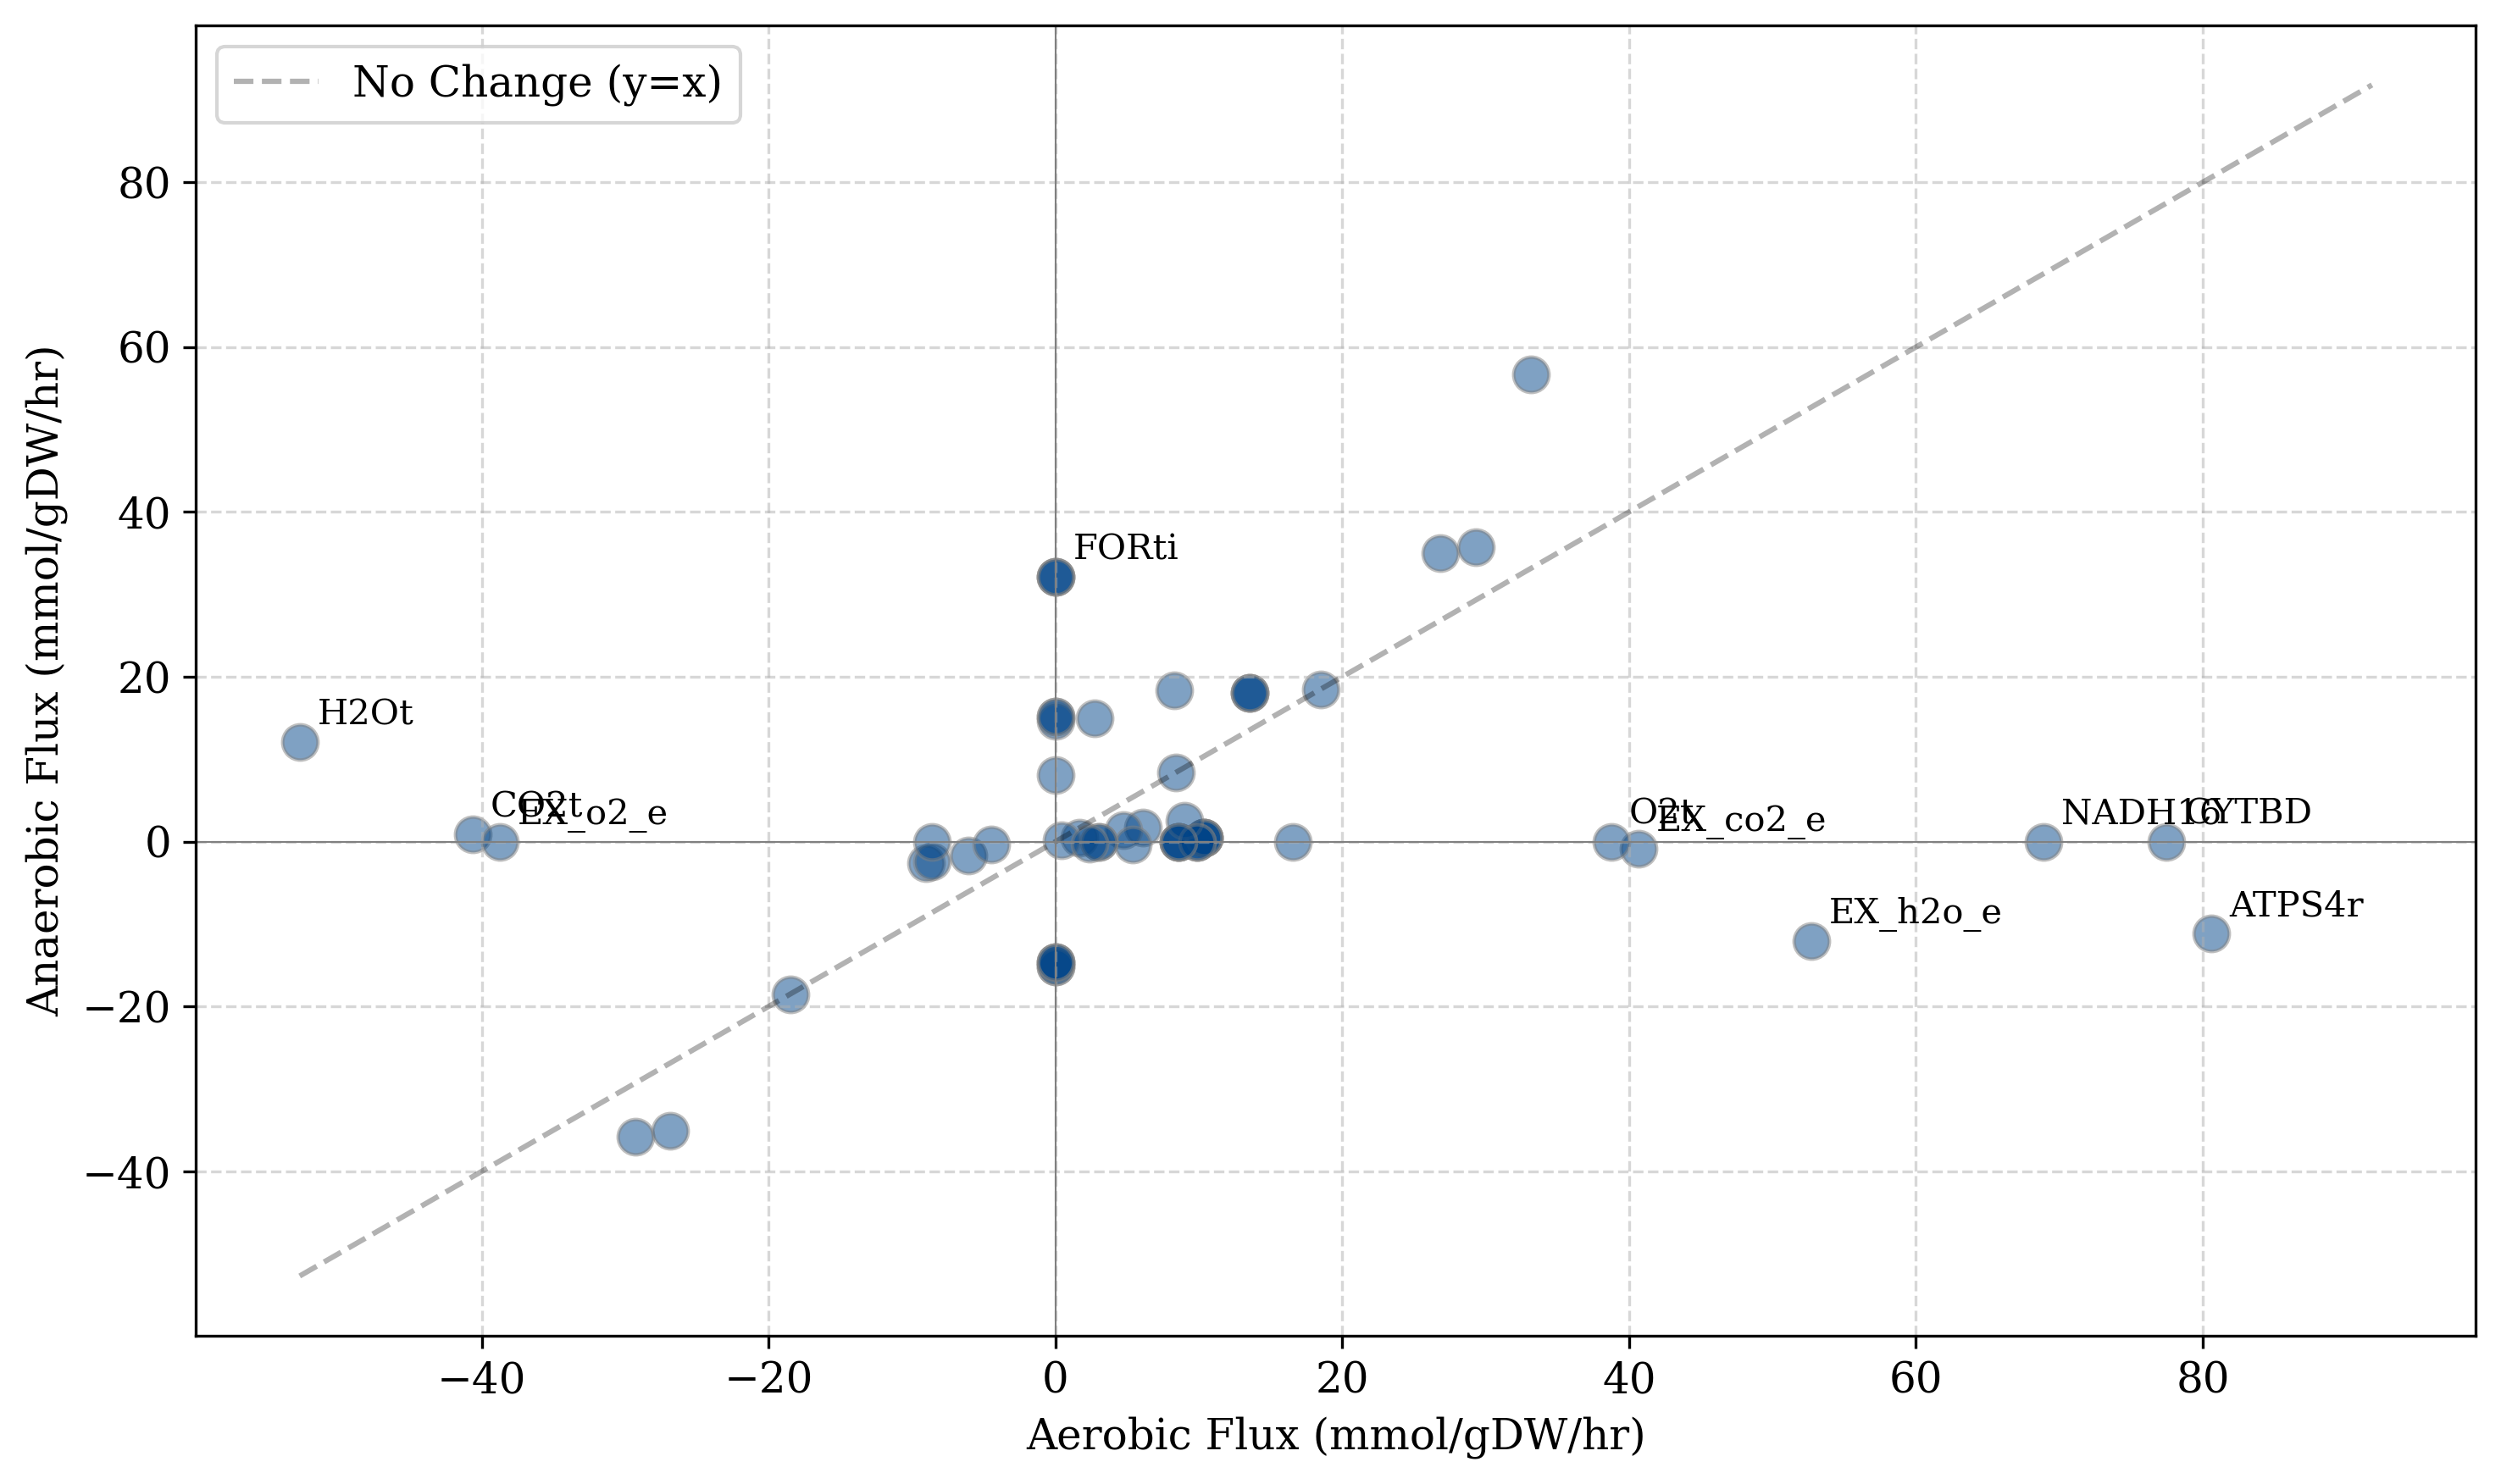

In [22]:
# Calculate the absolute difference between the two states to find the biggest shift
df_all['Shift_Magnitude'] = (df_all['Aerobic'] - df_all['Anaerobic']).abs()

# Filter out reactions that are zero in BOTH conditions
df_active = df_all[(df_all['Aerobic'].abs() > 1e-6) | (df_all['Anaerobic'].abs() > 1e-6)]

plt.figure(figsize=(10, 6))

# Plot active reactions
plt.scatter(df_active['Aerobic'], df_active['Anaerobic'], alpha=0.5, color='#004488', edgecolor='grey', s=100)

# Add the reference y=x diagonal line (Reactions that didn't change)
limits = [min(df_active.min()), max(df_active.max())]
plt.plot(limits, limits, 'k--', alpha=0.3, label='No Change (y=x)')

# Label the top 10 most shifted reactions
top_10_shifts = df_active.sort_values('Shift_Magnitude', ascending=False).head(10)
for idx, row in top_10_shifts.iterrows():
    plt.annotate(idx, (row['Aerobic'], row['Anaerobic']), 
                 xytext=(5, 5), textcoords='offset points', fontsize=10)

plt.xlabel('Aerobic Flux (mmol/gDW/hr)')
plt.ylabel('Anaerobic Flux (mmol/gDW/hr)')
plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
top_10_shifts

,Aerobic,Anaerobic,Shift_Magnitude
ATPS4r,80.606869,-1.118795e+01,91.794817
CYTBD,77.483169,-3.212810e-14,77.483169
NADH16,68.900971,-3.616570e-14,68.900971
EX_h2o_e,52.694337,-1.208789e+01,64.782228
H2Ot,-52.694337,1.208789e+01,64.782228
CO2t,-40.652701,8.407588e-01,41.493460
EX_co2_e,40.652701,-8.407588e-01,41.493460
O2t,38.741584,-1.606405e-14,38.741584
EX_o2_e,-38.741584,0.000000e+00,38.741584
FORti,0.000000,3.211939e+01,32.119392


<Figure size 2400x1200 with 0 Axes>

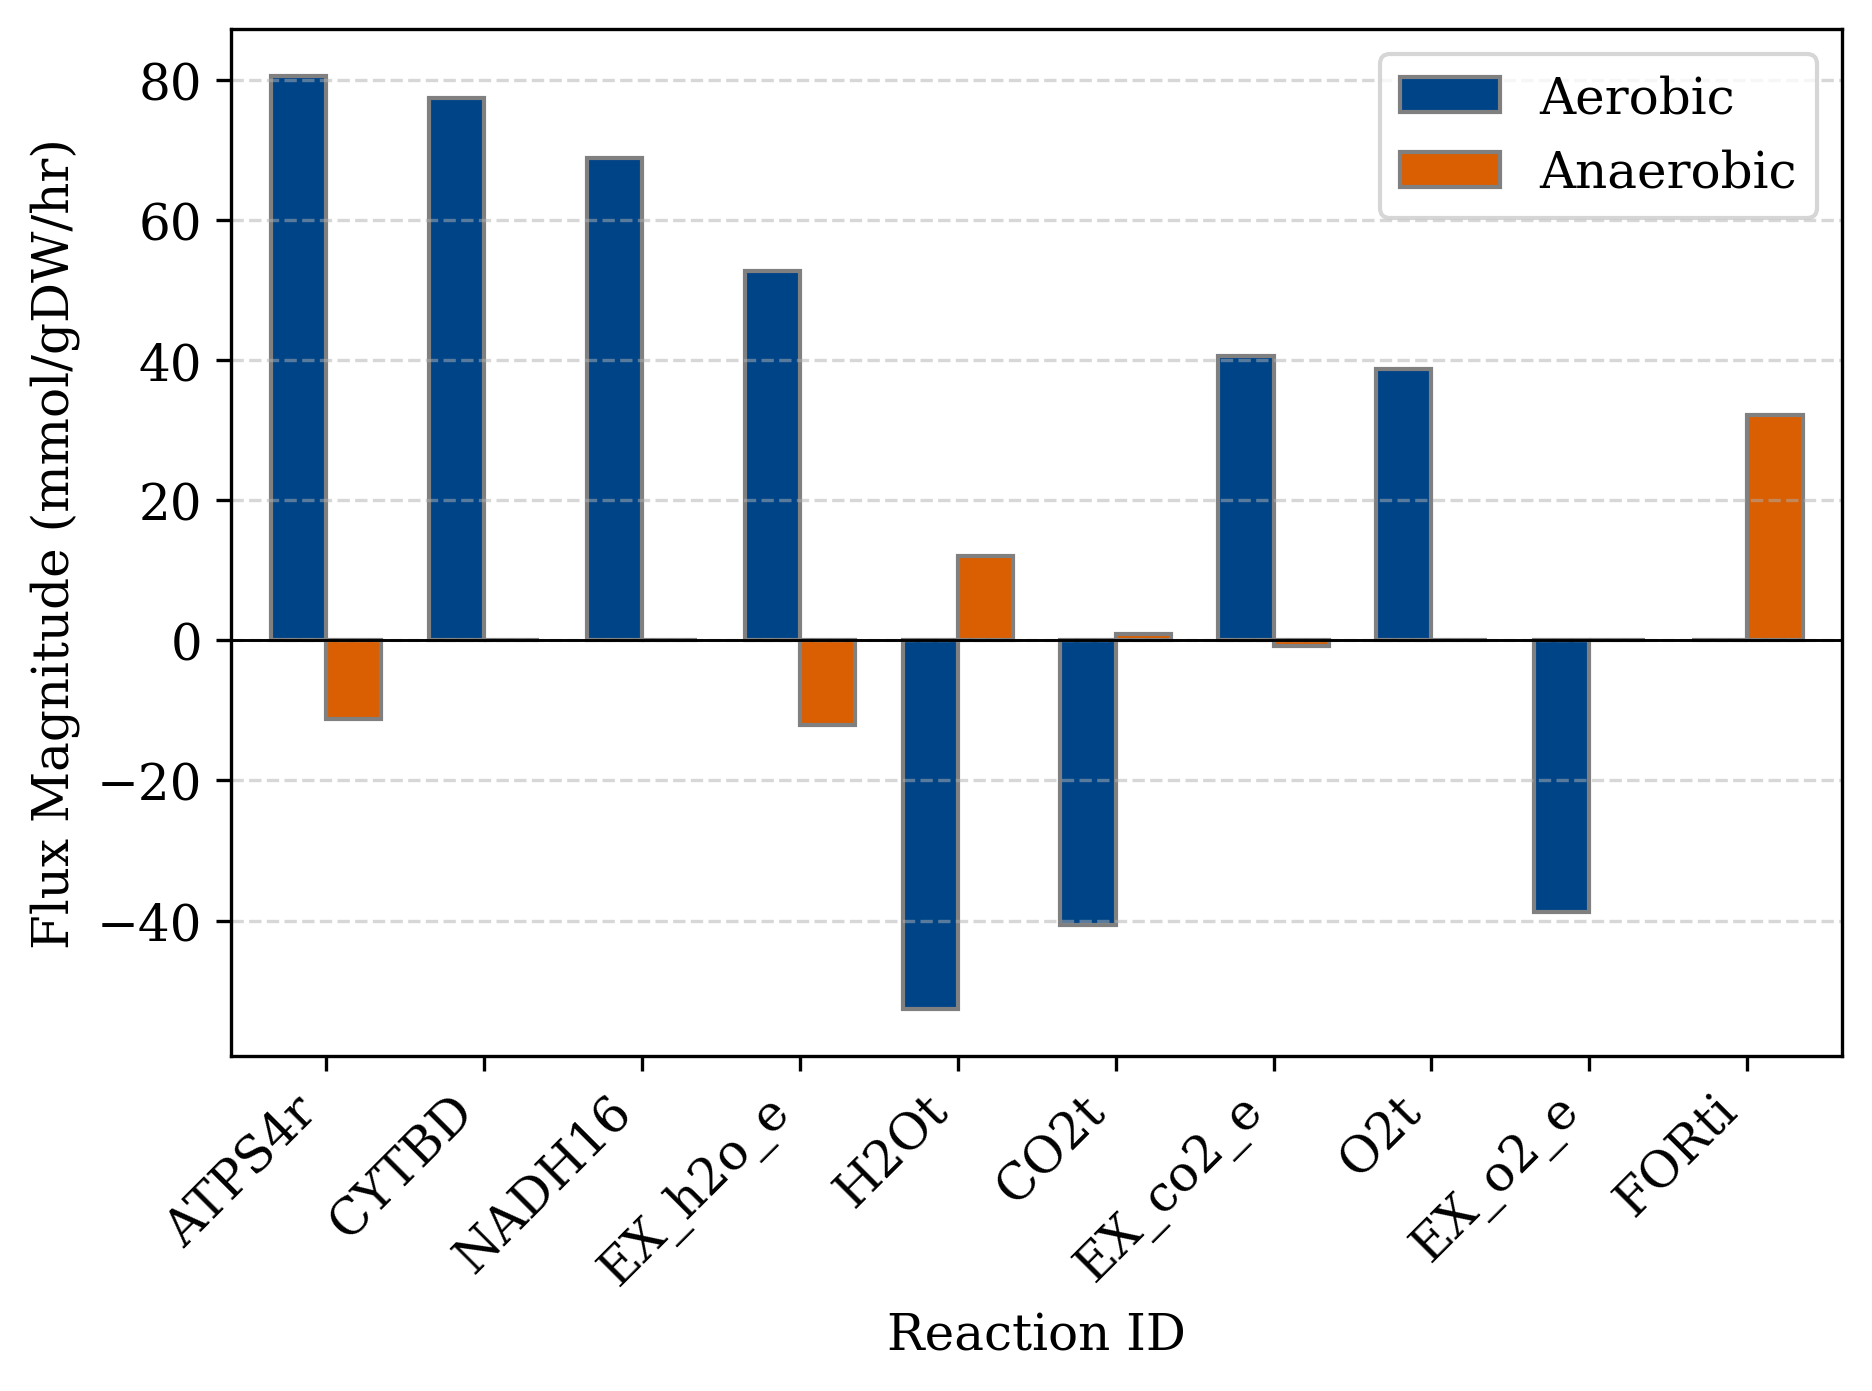

In [24]:
# Plot top 10 largest shifts as a grouped bar chart
plt.figure(figsize=(8, 4))
top_10_shifts[['Aerobic', 'Anaerobic']].plot(kind='bar', color=['#004488', '#d95f02'], edgecolor='grey', width=0.7)

plt.ylabel('Flux Magnitude (mmol/gDW/hr)')
plt.xlabel('Reaction ID')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(['Aerobic', 'Anaerobic'])
plt.axhline(0, color='black', linewidth=0.7) 
plt.tight_layout()
plt.show()

##### **Q 3.2**: Do aerobic vs anerobic grown modes have differences in ATP synthesis fluxes? (ATP synthesis is captured in one of the reactions).

In [25]:
# ATP Synthesis Analysis
aerobic_atp = df_active.loc['ATPS4r', 'Aerobic']
anaerobic_atp = df_active.loc['ATPS4r', 'Anaerobic']

print(f"Aerobic ATP flux (ATPS4r):   {aerobic_atp:>6.2f} mmol/gDW/hr")
print(f"Anaerobic ATP flux (ATPS4r): {anaerobic_atp:>6.2f} mmol/gDW/hr")

Aerobic ATP flux (ATPS4r):    80.61 mmol/gDW/hr
Anaerobic ATP flux (ATPS4r): -11.19 mmol/gDW/hr


##### **Q 3.3**: Reproduce Example 4 then chose a different exchange reaction to use as the main substrate for growth. Describe quantitatively how this impacts the growth and flux through pathways. Visualize this through plots which help you explain the changes in fluxes. (MATLAB: Note that when there is no feasible solution FBA produces a `NaN`).

In [26]:
# Replicate Example 4: Growth on alternate substrates (Succinate)

# Reset the model & Set glucose = 0 & Set aerobic
model = cobra.io.load_model("textbook")
model.reactions.EX_glc__D_e.lower_bound = 0
model.reactions.EX_o2_e.lower_bound = -1000

# Set Succinate uptake to -20
model.reactions.EX_succ_e.lower_bound = -20
solution_succinate = model.optimize()
print(f"Growth rate on Succinate (Aerobic): {solution_succinate.objective_value:.4f} hr^-1")

# Verify Anaerobic Succinate is infeasible (as in the MATLAB tutorial)
model.reactions.EX_o2_e.lower_bound = 0
solution_succinate_anaerobic = model.optimize()
solution_succinate_anaerobic.status

Growth rate on Succinate (Aerobic): 0.8401 hr^-1


'infeasible'

In [27]:
# Different Substrate Example: Pyruvate

# Reset model & Set aerobic & Set glucose = 0 & Set Pyruvate uptake
model = cobra.io.load_model("textbook")
model.reactions.EX_o2_e.lower_bound = -1000
model.reactions.EX_succ_e.lower_bound = 0
model.reactions.EX_pyr_e.lower_bound = -20

solution_pyruvate = model.optimize()
print(f"Growth rate on Pyruvate (Aerobic):  {solution_pyruvate.objective_value:.4f} hr^-1")

Growth rate on Pyruvate (Aerobic):  1.5546 hr^-1


In [28]:
# Quantitative Comparison: Glucose vs. Succinate vs. Pyruvate

# Run Glucose at -20 for a fair 1-to-1-to-1 comparison
model = cobra.io.load_model("textbook")
model.reactions.EX_o2_e.lower_bound = -1000
model.reactions.EX_succ_e.lower_bound = 0
model.reactions.EX_pyr_e.lower_bound = 0
model.reactions.EX_glc__D_e.lower_bound = -20
solution_glucose = model.optimize()
print(f"Growth rate on Glucose (Aerobic):   {solution_glucose.objective_value:.4f} hr^-1\n")

Growth rate on Glucose (Aerobic):   1.7906 hr^-1



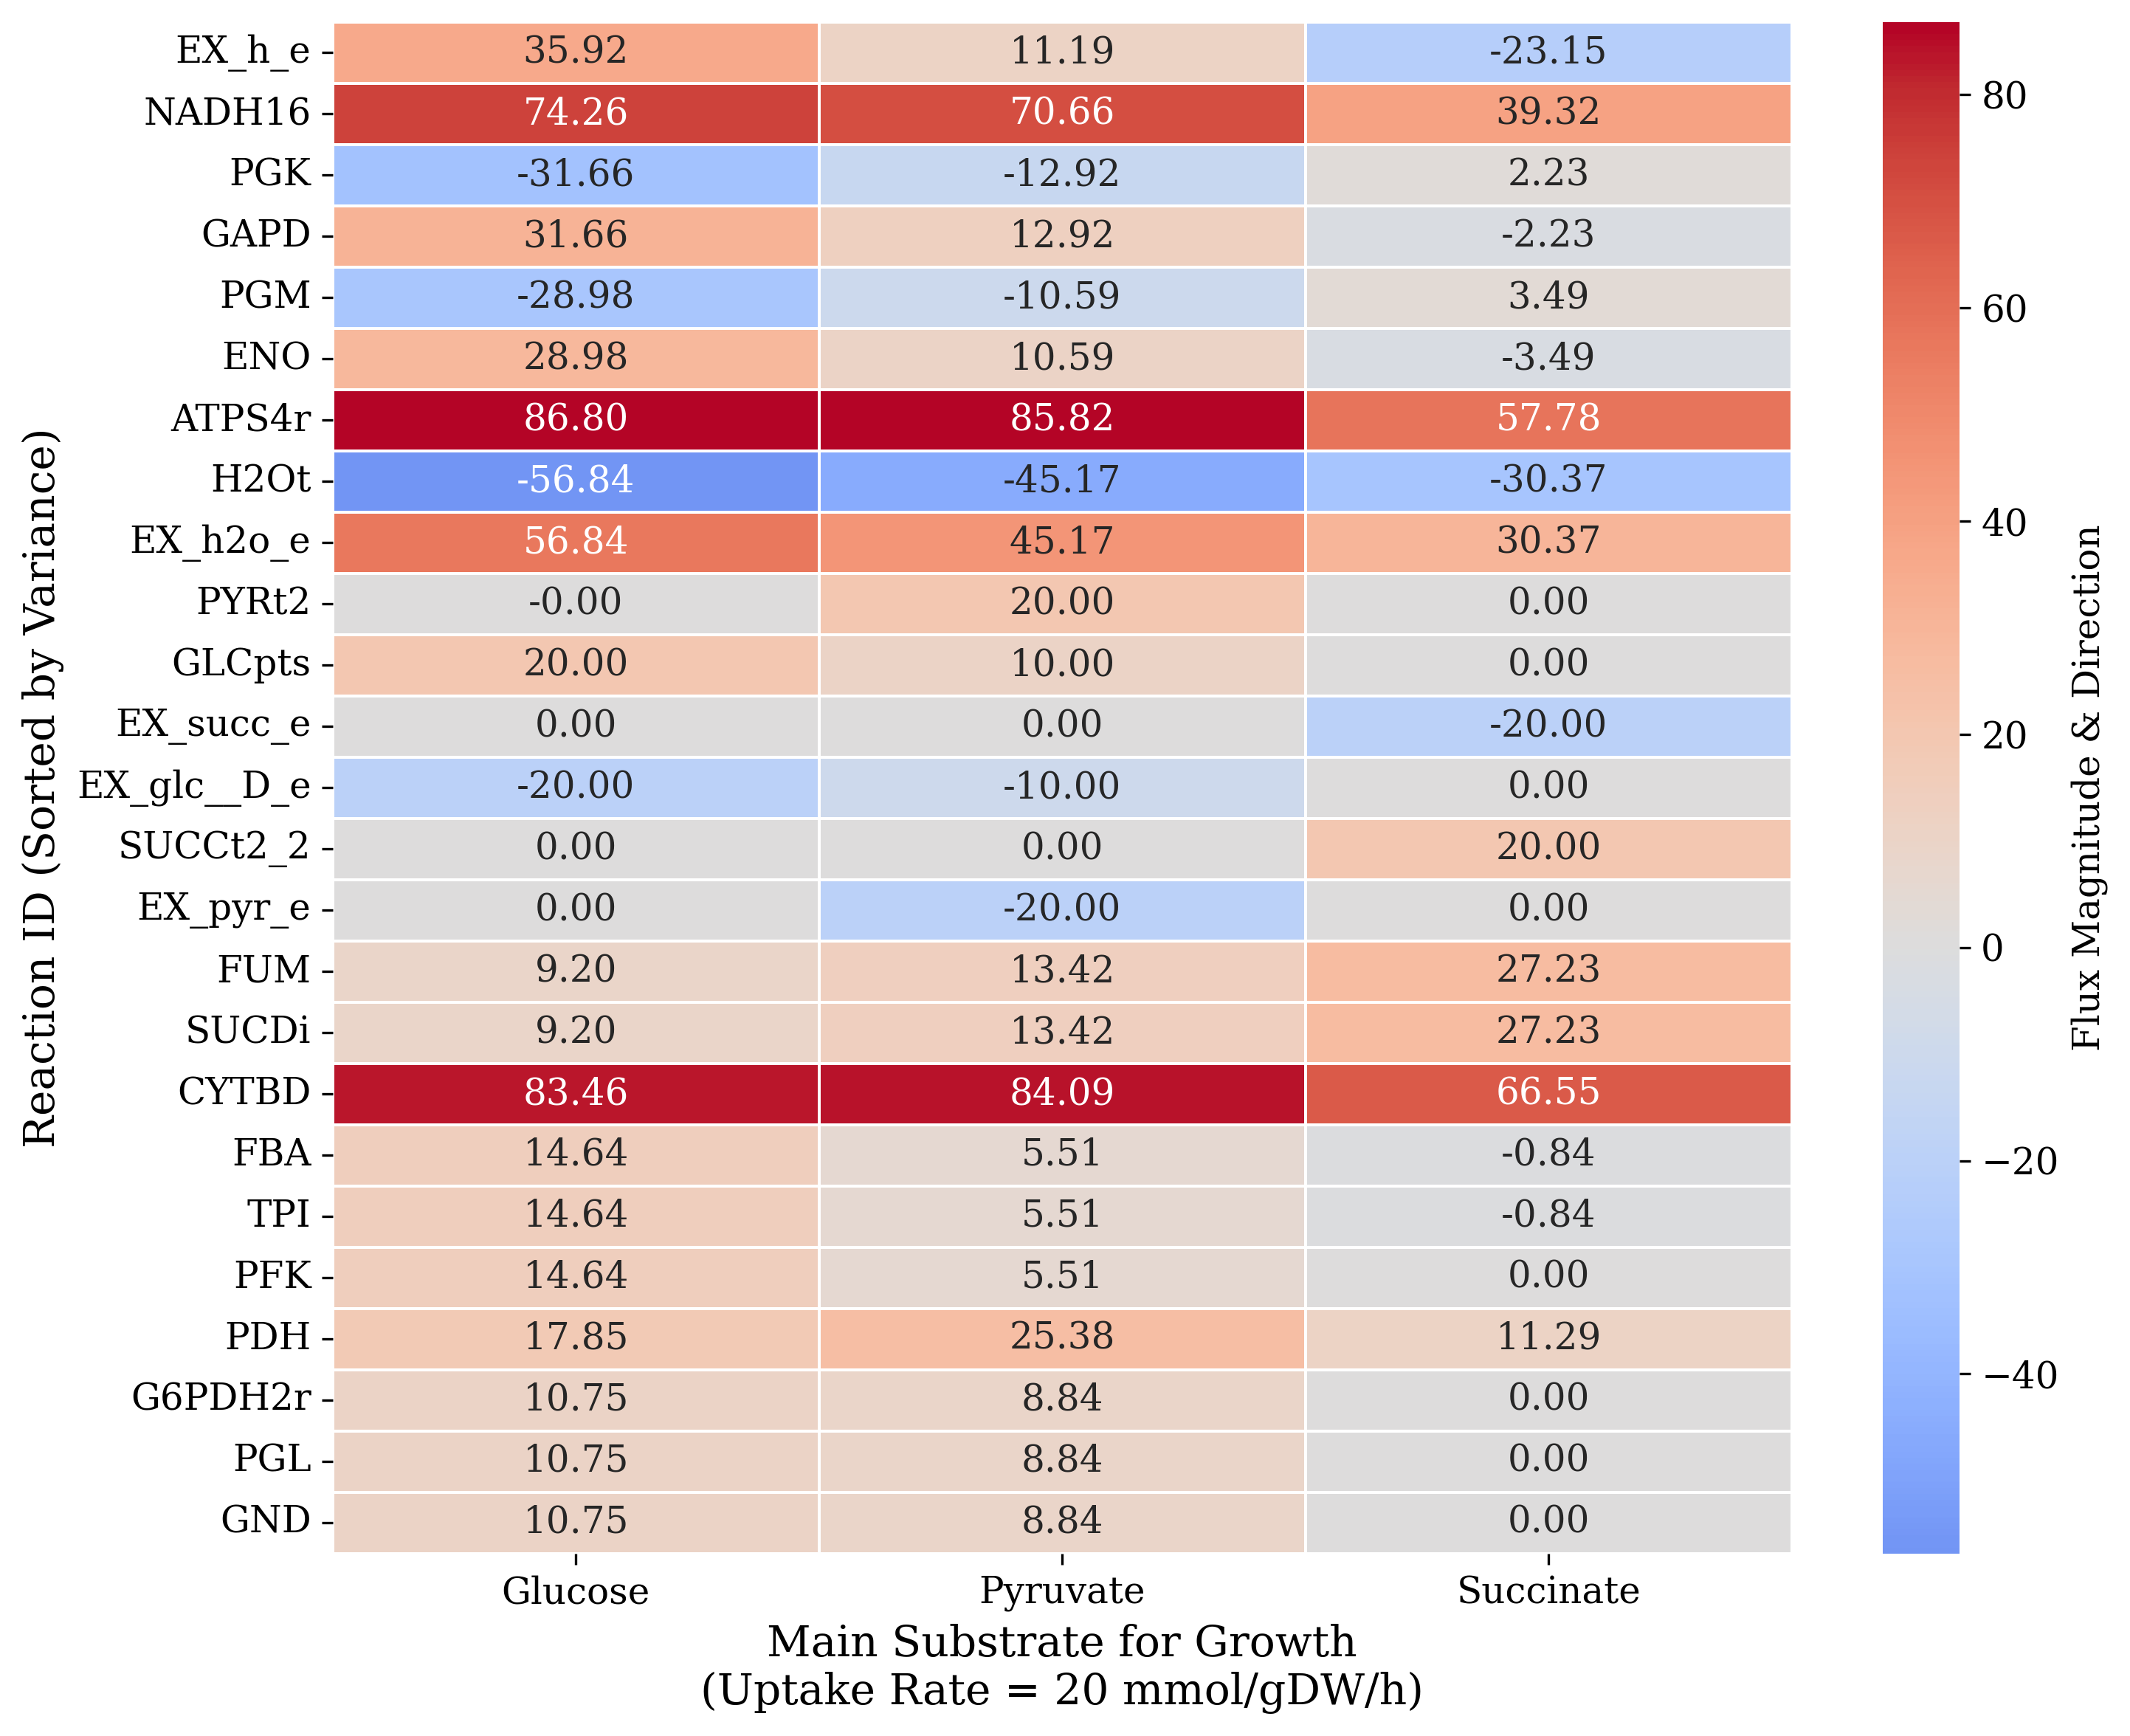

In [29]:
# Comparison Visualization

# Gather fluxes into a single DataFrame
df_subs = pd.DataFrame({
    'Glucose': solution_glucose.fluxes,
    'Pyruvate': solution_pyruvate.fluxes,
    'Succinate': solution_succinate.fluxes
})

# Calculate the maximum and minimum flux for each reaction across the 3 substrates
df_subs['max_flux'] = df_subs.max(axis=1)
df_subs['min_flux'] = df_subs.min(axis=1)
df_subs['flux_range'] = df_subs['max_flux'] - df_subs['min_flux']

# Filter 1: Active Reaction (Non-zero in at least ONE condition)
df_active = df_subs[(df_subs['max_flux'].abs() > 1e-8) | (df_subs['min_flux'].abs() > 1e-6)]

# Filter 2: Significant change (Range > 0)
df_dynamic = df_active[df_active['flux_range'] > 1e-8].copy()

# Sort by variance
df_dynamic = df_dynamic.sort_values('flux_range', ascending=False)

df_clean = df_dynamic.drop(columns=['max_flux', 'min_flux', 'flux_range'])


# Heatmap Visualization
# We plot the top 25 most variable reactions
top_n = 25
df_top = df_clean.head(top_n)

plt.figure(figsize=(10, 8))
sns.heatmap(df_top, annot=True, fmt=".2f", cmap="coolwarm", center=0, 
            linewidths=0.5, cbar_kws={'label': 'Flux Magnitude & Direction'})

plt.ylabel("Reaction ID (Sorted by Variance)", fontsize=14)
plt.xlabel("Main Substrate for Growth\n(Uptake Rate = 20 mmol/gDW/h)", fontsize=14)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

##### **Bonus**: Modify the cost function to both maximize growth and minimize ATP production.

In [30]:
# Reset to Baseline Aerobic Glucose
model = cobra.io.load_model("textbook")
model.reactions.EX_glc__D_e.lower_bound = -18.5
model.reactions.EX_o2_e.lower_bound = -1000
model.reactions.EX_pyr_e.lower_bound = 0
model.reactions.EX_succ_e.lower_bound = 0

biomass_rxn = model.reactions.get_by_id("Biomass_Ecoli_core")
atp_rxn = model.reactions.get_by_id("ATPS4r")

# Baseline FBA (Maximize Growth Only)
# Standard single objective
model.objective = biomass_rxn
sol_baseline = model.optimize()

print("--- Baseline (Maximize Growth Only) ---")
print(f"Objective Value: {sol_baseline.objective_value:.4f}")
print(f"Growth Rate:     {sol_baseline.fluxes[biomass_rxn.id]:.4f} hr^-1")
print(f"ATP Production:  {sol_baseline.fluxes[atp_rxn.id]:.2f} mmol/gDW/hr\n\n")


# Multi-Objective FBA (Max Growth & Min ATP)
# COBRApy lets us pass a dictionary to define weighted objectives
# We set Biomass weight to 1.0, and ATPS4r weight to a negative penalty (e.g., -0.01, -0.02)

weights = [0.01, 0.02]
for weight in weights:
    model.objective = {biomass_rxn: 1.0, atp_rxn: -weight}
    sol_multi_obj = model.optimize()

    # Compare the Results
    print(f"--- Multi-Objective (Max Growth - {weight} * ATP) ---")
    print(f"Objective Value: {sol_multi_obj.objective_value:.4f}")
    print(f"Growth Rate:     {sol_multi_obj.fluxes[biomass_rxn.id]:.4f} hr^-1")
    print(f"ATP Production:  {sol_multi_obj.fluxes[atp_rxn.id]:.2f} mmol/gDW/hr\n")

    # Let's see if it shifted the rest of the network to be more "ATP efficient"
    # by checking if the total flux sum decreased
    print(f"Total Absolute Flux (Baseline): {sol_baseline.fluxes.abs().sum():.2f}")
    print(f"Total Absolute Flux (Multi):    {sol_multi_obj.fluxes.abs().sum():.2f}\n\n")

--- Baseline (Maximize Growth Only) ---
Objective Value: 1.6531
Growth Rate:     1.6531 hr^-1
ATP Production:  80.61 mmol/gDW/hr


--- Multi-Objective (Max Growth - 0.01 * ATP) ---
Objective Value: 0.9097
Growth Rate:     1.6329 hr^-1
ATP Production:  72.32 mmol/gDW/hr

Total Absolute Flux (Baseline): 928.18
Total Absolute Flux (Multi):    967.99


--- Multi-Objective (Max Growth - 0.02 * ATP) ---
Objective Value: 1.3122
Growth Rate:     0.0000 hr^-1
ATP Production:  -65.61 mmol/gDW/hr

Total Absolute Flux (Baseline): 928.18
Total Absolute Flux (Multi):    1069.13


